### Text EDA and Baseline NLP
### ADS-509 Final Project

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Make plots look nicer
sns.set(style="whitegrid")

In [23]:
import os
print(os.getcwd())


c:\Users\kiara\Documents\ADS-509-Final\notebooks


In [24]:
# datasets
indeed = pd.read_csv("jobs_indeed_20260202_180907.csv")
linkedin = pd.read_csv("jobs_linkedin_20260202_180156.csv")

print("Indeed Shape:", indeed.shape)
print("LinkedIn Shape:", linkedin.shape)

Indeed Shape: (100, 10)
LinkedIn Shape: (100, 10)


In [25]:
# Inspect Columns
print("Indeed Columns:")
print(indeed.columns)

print("\nLinkedIn Columns:")
print(linkedin.columns)


Indeed Columns:
Index(['source', 'search_term', 'title', 'company', 'location', 'date_posted',
       'job_type', 'description', 'job_url', 'text'],
      dtype='object')

LinkedIn Columns:
Index(['source', 'search_term', 'title', 'company', 'location', 'date_posted',
       'job_type', 'description', 'job_url', 'text'],
      dtype='object')


In [26]:
# Missing Text Check
text_col = "text"

print("Missing text values (Indeed):", indeed[text_col].isnull().sum())
print("Total rows (Indeed):", len(indeed))

Missing text values (Indeed): 0
Total rows (Indeed): 100


In [27]:
# EDA for Indeed Text
text_col = "description"  

indeed_text = indeed[text_col].dropna()

print("Total Indeed job descriptions:", len(indeed_text))
indeed_text.head()

Total Indeed job descriptions: 100


0    The pay range is $132,000\.00 \- $286,000\.00 ...
1    The pay range is $132,000\.00 \- $286,000\.00 ...
2    The pay range is $132,000\.00 \- $286,000\.00 ...
3    The pay range is $98,000\.00 \- $211,000\.00 P...
4    The Opportunity Machine learning lies at the c...
Name: description, dtype: object

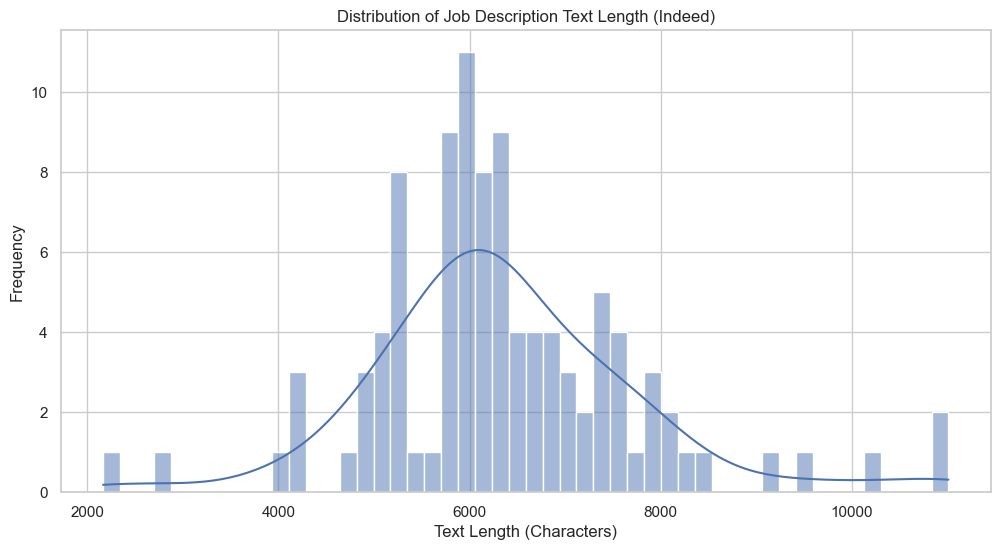

In [28]:
# Text length distribution
indeed["text_length"] = indeed[text_col].astype(str).apply(len)

plt.figure(figsize=(12,6))
sns.histplot(indeed["text_length"], bins=50, kde=True)
plt.title("Distribution of Job Description Text Length (Indeed)")
plt.xlabel("Text Length (Characters)")
plt.ylabel("Frequency")
plt.show()

In [29]:
### Word Frequencies
vectorizer = CountVectorizer(stop_words="english", max_features=20)
X_counts = vectorizer.fit_transform(indeed_text)

indeed_word_counts = pd.DataFrame({
    "word": vectorizer.get_feature_names_out(),
    "count": X_counts.sum(axis=0).A1
}).sort_values(by="count", ascending=False)

indeed_word_counts

,word,count
9,experience,868
2,amazon,693
7,data,473
19,work,470
17,team,393
13,learning,393
11,including,370
15,position,363
1,ai,357
6,customers,356


In [36]:
# TF-IDF Keywords
tfidf = TfidfVectorizer(stop_words="english", max_features=20)
X_tfidf = tfidf.fit_transform(indeed_text)

indeed_tfidf = pd.DataFrame({
    "word": tfidf.get_feature_names_out(),
    "score": X_tfidf.sum(axis=0).A1
}).sort_values(by="score", ascending=False)

indeed_tfidf

,word,score
9,experience,32.947572
2,amazon,29.875947
7,data,20.507918
1,ai,19.204015
19,work,18.126395
17,team,17.374582
13,learning,15.834023
0,00,15.396655
16,prime,15.384959
15,position,15.112589


In [37]:
linkedin_text = linkedin[text_col].dropna()

vectorizer = CountVectorizer(stop_words="english", max_features=20)
X_counts_li = vectorizer.fit_transform(linkedin_text)

linkedin_word_counts = pd.DataFrame({
    "word": vectorizer.get_feature_names_out(),
    "count": X_counts_li.sum(axis=0).A1
}).sort_values(by="count", ascending=False)

linkedin_word_counts

,word,count
5,data,759
7,experience,508
19,work,325
13,product,300
9,learning,273
0,ai,267
14,role,234
17,team,233
12,models,232
2,benefits,207


#### Top Frequency Bar Chart

C:\Users\kiara\AppData\Local\Temp\ipykernel_30536\2927619806.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=word_counts, x="count", y="word", palette="viridis")


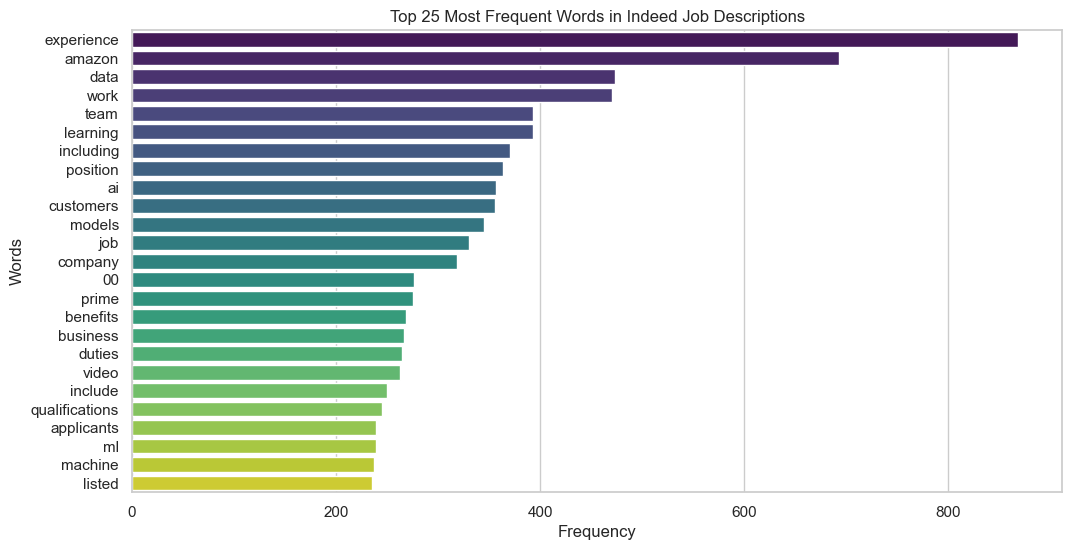

In [38]:
from sklearn.feature_extraction.text import CountVectorizer

text_col = "description"  # update if needed
text_data = indeed[text_col].dropna()

vectorizer = CountVectorizer(stop_words="english", max_features=25)
X_counts = vectorizer.fit_transform(text_data)

word_counts = pd.DataFrame({
    "word": vectorizer.get_feature_names_out(),
    "count": X_counts.sum(axis=0).A1
}).sort_values(by="count", ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(data=word_counts, x="count", y="word", palette="viridis")
plt.title("Top 25 Most Frequent Words in Indeed Job Descriptions")
plt.xlabel("Frequency")
plt.ylabel("Words")
plt.show()

#### Text Length Distribution

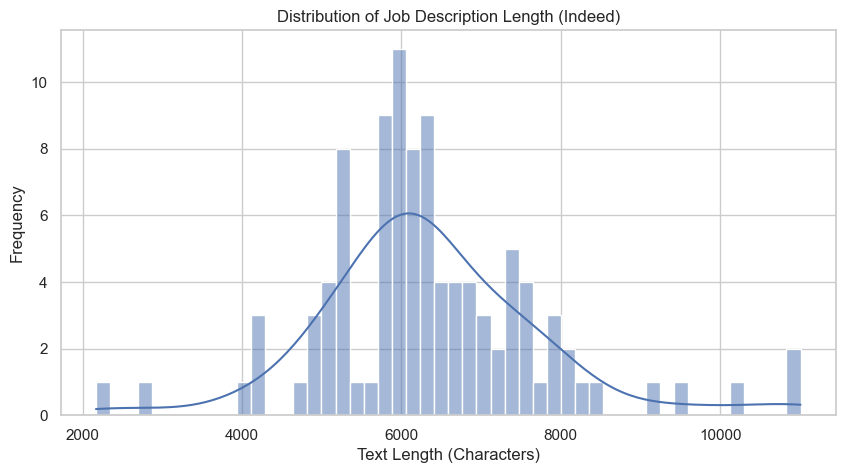

In [32]:
indeed["text_length"] = indeed[text_col].astype(str).apply(len)

plt.figure(figsize=(10,5))
sns.histplot(indeed["text_length"], bins=50, kde=True)
plt.title("Distribution of Job Description Length (Indeed)")
plt.xlabel("Text Length (Characters)")
plt.ylabel("Frequency")
plt.show()

#### TF-IDF Keyword Importance

C:\Users\kiara\AppData\Local\Temp\ipykernel_30536\1108374578.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tfidf_df, x="score", y="word", palette="magma")


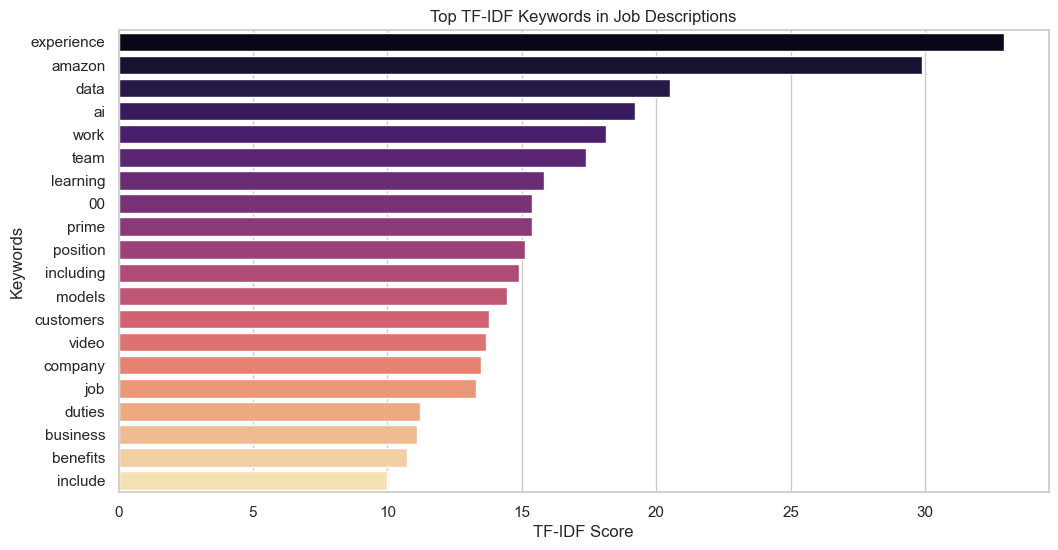

In [33]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words="english", max_features=20)
X_tfidf = tfidf.fit_transform(text_data)

tfidf_df = pd.DataFrame({
    "word": tfidf.get_feature_names_out(),
    "score": X_tfidf.sum(axis=0).A1
}).sort_values(by="score", ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(data=tfidf_df, x="score", y="word", palette="magma")
plt.title("Top TF-IDF Keywords in Job Descriptions")
plt.xlabel("TF-IDF Score")
plt.ylabel("Keywords")
plt.show()


#### Most Mentioned Skills

C:\Users\kiara\AppData\Local\Temp\ipykernel_30536\4163525967.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=skill_counts.values, y=skill_counts.index, palette="coolwarm")


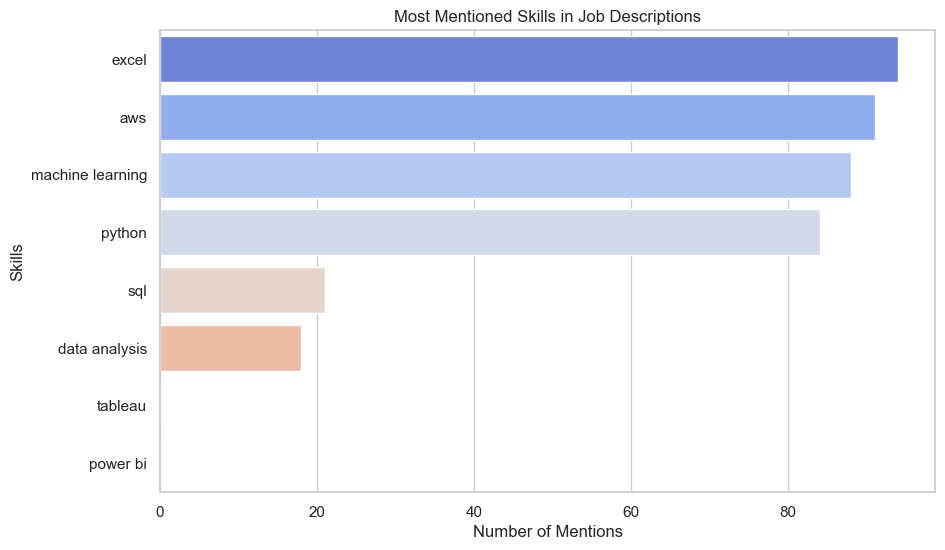

In [34]:
skills = ["python", "sql", "machine learning", "excel", "aws", "tableau", "power bi", "data analysis"]

for skill in skills:
    indeed[skill] = text_data.str.lower().str.contains(skill, na=False)

skill_counts = indeed[skills].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=skill_counts.values, y=skill_counts.index, palette="coolwarm")
plt.title("Most Mentioned Skills in Job Descriptions")
plt.xlabel("Number of Mentions")
plt.ylabel("Skills")
plt.show()


#### World Cloud

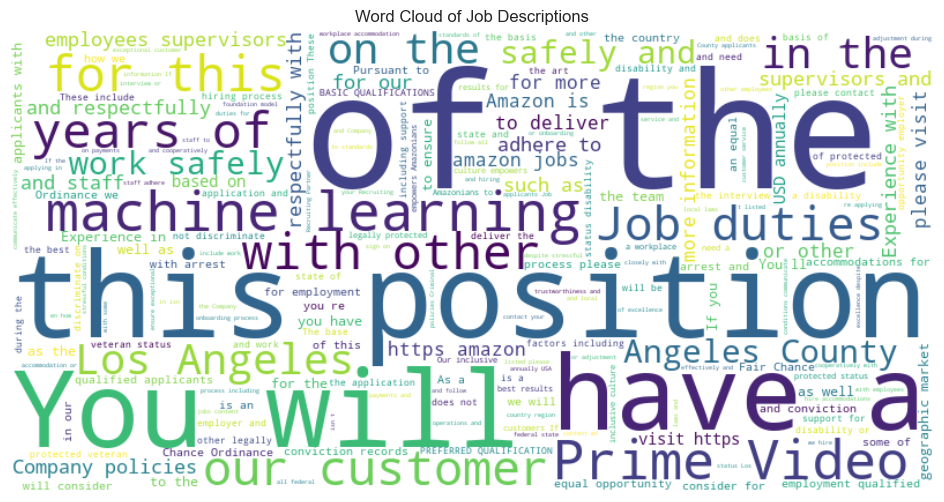

In [35]:
from wordcloud import WordCloud

all_text = " ".join(text_data.astype(str))

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white",
    stopwords="english"
).generate(all_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Job Descriptions")
plt.show()

# Baseline NLP: Text Preprocessing

In [39]:
import re

# Use text column 
text_col = "text"

# Clean text
def clean_text(text):
    text = str(text).lower()  # lowercase
    text = re.sub(r"[^\w\s]", "", text)  # remove punctuation
    text = re.sub(r"\d+", "", text)  # remove numbers
    return text

indeed["clean_text"] = indeed[text_col].apply(clean_text)

indeed["clean_text"].head()

0    lead applied data scientist  search and rankin...
1    lead data scientist  last mile supply chain op...
2    lead machine learning engineer  personalizatio...
3    sr applied data scientist  search nlp query un...
4    senior machine learning scientist oligonucleot...
Name: clean_text, dtype: object

#### Baseline NLP: TF-IDF Keyword Extraction

In [40]:
from sklearn.feature_extraction.text import TfidfVectorizer

clean_text_data = indeed["clean_text"].dropna()

tfidf = TfidfVectorizer(stop_words="english", max_features=25)
X_tfidf = tfidf.fit_transform(clean_text_data)

tfidf_keywords = pd.DataFrame({
    "Keyword": tfidf.get_feature_names_out(),
    "TF-IDF Score": X_tfidf.sum(axis=0).A1
}).sort_values(by="TF-IDF Score", ascending=False)

tfidf_keywords

,Keyword,TF-IDF Score
8,experience,34.032871
6,data,21.498045
1,amazon,19.869435
0,ai,18.610871
24,work,17.781732
22,team,17.127536
18,prime,16.184638
12,learning,15.930630
17,position,15.501811
10,including,15.372261


#### Baseline NLP: Skills and Tools Mention Analysis


In [41]:
skills = [
    "python", "sql", "machine learning", "data analysis",
    "excel", "aws", "tableau", "power bi", "statistics"
]

for skill in skills:
    indeed[skill] = indeed["clean_text"].str.contains(skill, na=False)

skill_counts = indeed[skills].sum().sort_values(ascending=False)

skill_counts

excel               94
aws                 91
machine learning    90
python              84
sql                 21
data analysis       18
statistics          14
tableau              0
power bi             0
dtype: int64

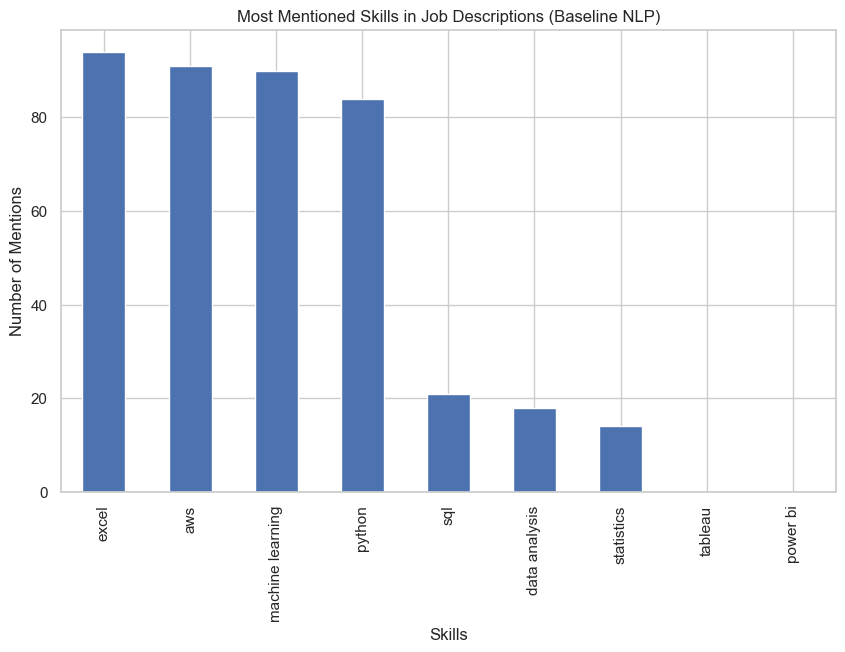

In [42]:
plt.figure(figsize=(10,6))
skill_counts.plot(kind="bar")
plt.title("Most Mentioned Skills in Job Descriptions (Baseline NLP)")
plt.xlabel("Skills")
plt.ylabel("Number of Mentions")
plt.show()

#### Baseline NLP: Bigram Analysis

In [43]:
from sklearn.feature_extraction.text import CountVectorizer

bigram_vectorizer = CountVectorizer(
    stop_words="english",
    ngram_range=(2,2),  # bigrams
    max_features=20
)

X_bigrams = bigram_vectorizer.fit_transform(clean_text_data)

bigrams_df = pd.DataFrame({
    "Bigram": bigram_vectorizer.get_feature_names_out(),
    "Frequency": X_bigrams.sum(axis=0).A1
}).sort_values(by="Frequency", ascending=False)

bigrams_df

,Bigram,Frequency
13,machine learning,235
15,prime video,227
12,los angeles,174
11,job duties,174
14,position include,174
19,work safely,170
8,employees supervisors,170
0,angeles county,170
17,supervisors staff,170
4,company policies,170


#### Baseline NLP: Skills and Tools Mention Analysis

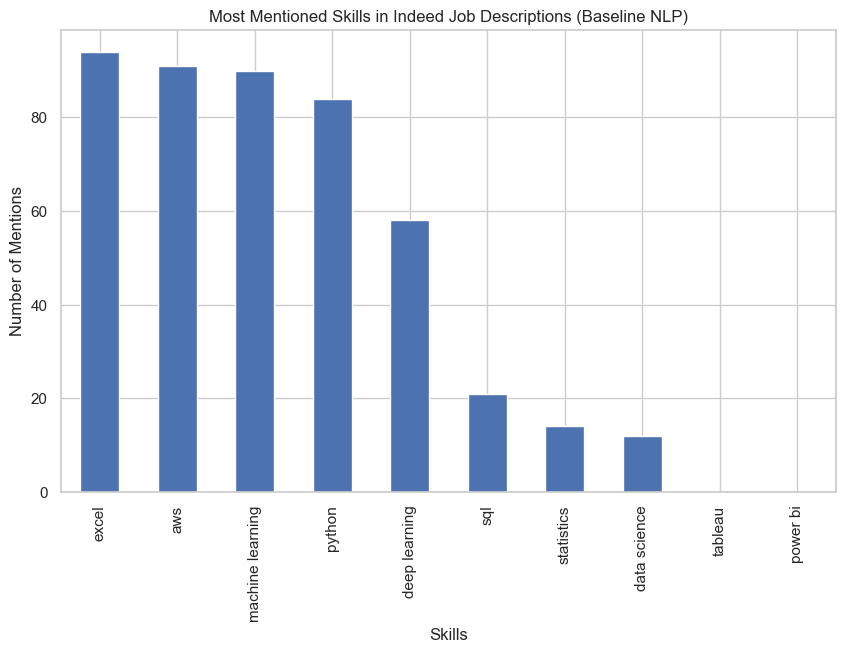

In [44]:
skills = [
    "python", "sql", "machine learning", "aws",
    "excel", "tableau", "power bi", "data science",
    "deep learning", "statistics"
]

for skill in skills:
    indeed[skill] = indeed["text"].str.lower().str.contains(skill, na=False)

skill_counts = indeed[skills].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
skill_counts.plot(kind="bar")
plt.title("Most Mentioned Skills in Indeed Job Descriptions (Baseline NLP)")
plt.xlabel("Skills")
plt.ylabel("Number of Mentions")
plt.show()


#### Baseline NLP Summary

A baseline NLP analysis was conducted using traditional text mining methods, including word frequency analysis and TF-IDF keyword extraction on the job description text. The results show that terms such as “data,” “AI,” “learning,” and “experience” appear frequently, indicating a strong emphasis on technical and data-related roles within the dataset. These interpretable, non-LLM methods establish a foundational benchmark that can later be compared against more advanced generative AI or embedding-based approaches.

